In [7]:
"""
A - [126, 187, 65]
B - [221, 115, 172]
"""

'\nA - [126, 187, 65]\nB - [221, 115, 172]\n'

In [8]:
import pandas
frame = pandas.read_excel('./dats/dataset_bi.xlsx', )
frame

,metal_A,num_a_A,rad_c_A,neg_p_A,neg_a_A,affin_A,ion_1_A,ion_2_A,num_v_A,num_d_A,...,affin_B,ion_1_B,ion_2_B,num_v_B,num_d_B,d_cen_B,d_wid_B,d_ske_B,e_ads_DNB,e_ads_H
0,Ag,47,165,1.93,1.87,126,731.0,2070.0,11,20,...,64,760.4,1648.0,9,7,-1.6465,2.0337,-0.0162,-2.288,0.265
1,Ag,47,165,1.93,1.87,126,731.0,2070.0,11,20,...,37,558.3,1820.7,3,20,-14.4874,0.8394,-0.0002,-1.121,-0.622
2,Ag,47,165,1.93,1.87,126,731.0,2070.0,11,20,...,-50,717.3,1509.0,7,5,-0.6804,2.4651,-0.0132,-2.069,0.294
3,Ag,47,165,1.93,1.87,126,731.0,2070.0,11,20,...,89,652.1,1380.0,5,14,2.7349,4.5840,0.0160,-1.925,0.032
4,Ag,47,165,1.93,1.87,126,731.0,2070.0,11,20,...,205,870.0,1791.0,10,29,-2.6283,2.7355,-0.0072,-1.780,-0.638
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
94,Ti,22,176,1.54,1.38,7,658.8,1309.8,4,2,...,7,658.8,1309.8,4,2,1.4304,2.5346,0.0014,-2.254,0.315
95,Zr,40,206,1.33,1.32,42,640.1,1270.0,4,12,...,42,640.1,1270.0,4,12,1.9245,3.6565,0.0000,-2.285,0.388
96,Fe,26,156,1.83,1.80,15,762.5,1561.9,8,6,...,15,762.5,1561.9,8,6,-1.4777,2.2461,-0.0186,-1.766,-0.268
97,Ir,77,180,2.20,1.68,151,880.0,1600.0,9,27,...,151,880.0,1600.0,9,27,-2.3657,3.3733,0.0000,-2.089,-1.136


In [9]:
import torch
import numpy
import pymodel
dict_dataset:pymodel.DictDataset = {}

# extract data from frame
array_data = numpy.delete(frame.values, [0, 13], axis=1).astype(float)
array_x = array_data[:, 0:-1].astype(float)
array_y = array_data[:, -1].astype(float)
# array to tensor
tensor_x = torch.tensor(array_x)  # (num_batch, num_input)
tensor_y = torch.tensor(array_y)  # (num_batch, num_output)
tensor_y = tensor_y.reshape(-1, 1)
# set float32
tensor_x = tensor_x.to(torch.float32)
tensor_y = tensor_y.to(torch.float32)
# normalize
tensor_x_mean = tensor_x.mean(dim=0)
tensor_x_std = tensor_x.std(dim=0)
tensor_x = (tensor_x - tensor_x_mean) / tensor_x_std
tensor_y_mean = tensor_y.mean(dim=0)
tensor_y_std = tensor_y.std(dim=0)
tensor_y = (tensor_y - tensor_y_mean) / tensor_y_std
# setup seed
seed = 0
device = 'cpu'
# dict_dataset 
torch.manual_seed(seed)
num_batch = tensor_x.shape[0]
num_train = int(0.8*num_batch)
ind_batch = torch.randperm(num_batch)
ind_train = ind_batch[:num_train]
ind_valid = ind_batch[num_train:]
dict_dataset = {
    'merge_x': tensor_x.to(device), 
    'merge_y': tensor_y.to(device), 
    'merge_x_mean': tensor_x_mean, 
    'merge_y_mean': tensor_y_mean, 
    'merge_x_std': tensor_x_std, 
    'merge_y_std': tensor_y_std, 
    'train_x': tensor_x[ind_train, :].to(device),
    'train_y': tensor_y[ind_train, :].to(device),
    'valid_x': tensor_x[ind_valid, :].to(device),
    'valid_y': tensor_y[ind_valid, :].to(device),}

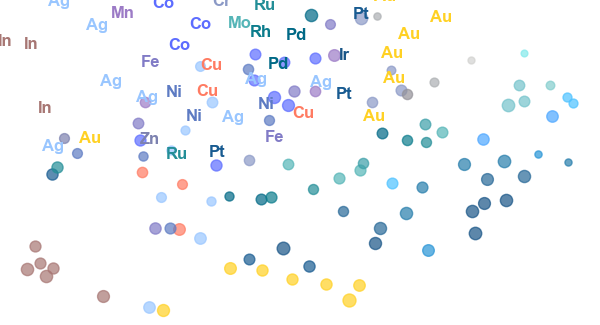

In [10]:
import pyexp
import pyatom
import pyatom.tool
import sklearn
import adjustText
%matplotlib ipympl

# create t-sne
tsne = sklearn.manifold.TSNE(
    n_components=2, perplexity=30, learning_rate=200, random_state=621)
array_coor_2d = tsne.fit_transform(tensor_x)

# load text position
array_text_2d = numpy.load('./dats/array_text_2d.npy',)

# fig
fig, ax = pyexp.initial_fig_ax(
    figsize=[6, 6.5/2], 
    flag_enable_spine=False, left=0, right=0, bottom=0, top=0)

# plot
array_scale = (tensor_y.max()-tensor_y).flatten().numpy()
array_scale = array_scale / array_scale.max()
array_markersize = 24 + 64*array_scale
array_alpha = 0.2 + 0.8*array_scale
for ii in range(array_coor_2d.shape[0]):
    coor_2d_elem = array_coor_2d[ii]
    text_2d_elem = array_text_2d[ii]
    str_elem = frame.values[ii][0] # A - 0; B - 13
    markersize_elem = array_markersize[ii]
    alpha_elem = array_alpha[ii]
    color_elem = numpy.array(
        pyatom.tool.database.get_info_elem(str_elem, 'color', 'color'))/255
    # scatter
    xx, yy = coor_2d_elem
    ax.scatter(
        x=xx, y=yy, 
        s=markersize_elem, color=color_elem, alpha=0.7)
    # text
    xx, yy = text_2d_elem
    text = ax.text(
        x=xx, y=yy, s=str_elem, 
        va='center', ha='center',
        color=color_elem, 
        fontsize=12, fontweight='bold', )
    
# region: save
pyexp.save_fig(fig=fig, )
# endregion

In [5]:
%pip install adjustText

Looking in indexes: https://mirrors.tuna.tsinghua.edu.cn/pypi/web/simple
Note: you may need to restart the kernel to use updated packages.
